# PYNQ MNIST — Softmax IP (K=10 padded to 128)

**K = 10** (actual classes) to **Padded to 128** (minimum 1 full scanner block)

### Architecture: 2-Pass Streaming
- **Pass 1**: Block-scan max + sum_exp (pre-scan eliminates per-beat rescaling)
- **Pass 2**: Normalize (exp2 × recip) to AXI-S output
- **Bus**: 128-bit AXI-Stream, 8 elements/beat, 333 MHz, 0 DSP, 2 BRAM

In [1]:
# =========================================================================
# Configuration & Hardware Setup
# =========================================================================
import os, time, math, csv, datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pynq import Overlay, allocate, MMIO
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, datasets

BITSTREAM = "my_softmax15.bit"
IP_NAME   = "softmax_dl2_v6_0"
DMA_NAME  = "axi_dma_0"
NUM_CLASSES = 10
MIN_PAD     = 128
K_IP        = max(NUM_CLASSES, MIN_PAD)  
IP_FCLK_HZ  = 333_000_000
AXIS_WIDTH  = 128            # 128-bit AXI-Stream
IN_FRAC = 12; OUT_FRAC = 15
N_TEST  = 10000
WEIGHTS = "lenet_mnist_trained.pth"
LOG_CSV = "mnist_v6_hw.csv"

print(f"Loading: {BITSTREAM}...")
overlay = Overlay(BITSTREAM)
dma = getattr(overlay, DMA_NAME)
dma_send = dma.sendchannel
dma_recv = dma.recvchannel
mmio = MMIO(overlay.ip_dict[IP_NAME]["phys_addr"], 0x10000)

# === v6.0 Register Map ===
REG_CTRL       = 0x00  # W: b0=start_p1, b1=start_p2, b2=clear_perf, b3=clear_error
REG_STATUS     = 0x04  # R: b0=p1_done, b1=p2_done, b2=busy, b3=error
REG_ARGMAX_IDX = 0x08
REG_ARGMAX_VAL = 0x0C
REG_TOTAL_LO   = 0x10; REG_TOTAL_HI  = 0x14
REG_P1_LO      = 0x18; REG_P1_HI     = 0x1C
REG_P2_LO      = 0x20; REG_P2_HI     = 0x24
REG_STALL_LO   = 0x28; REG_STALL_HI  = 0x2C
REG_K_CONFIG   = 0x30
REG_COMPUTE_LO = 0x34; REG_COMPUTE_HI = 0x38

# Control bits
CTRL_START_P1   = 0x01
CTRL_START_P2   = 0x02
CTRL_CLEAR_PERF = 0x04
CTRL_CLEAR_ERR  = 0x08

# Status bits
STATUS_P1_DONE = 0x01
STATUS_P2_DONE = 0x02
STATUS_BUSY    = 0x04
STATUS_ERROR   = 0x08

def rd64(lo, hi): return (mmio.read(hi) << 32) | mmio.read(lo)

N_BEATS   = K_IP // 8          # 128/8 = 16 beats
K_PADDED  = N_BEATS * 8        # 128
BUF_WORDS = N_BEATS * 4        # 64 uint32 words

try: in_buf.freebuffer(); out_buf.freebuffer()
except: pass
in_buf  = allocate(shape=(BUF_WORDS,), dtype=np.uint32)
out_buf = allocate(shape=(BUF_WORDS,), dtype=np.uint32)

mmio.write(REG_K_CONFIG, K_IP)

print(f"Ready! {IP_FCLK_HZ/1e6:.0f} MHz | PAR8 {AXIS_WIDTH}b | K={NUM_CLASSES}to{K_IP} (padded) | {N_BEATS} beats")
print(f"Architecture: v6.0 Block-Scan Lookahead | 0 DSP, 2 BRAM")
print(f"Padding: {NUM_CLASSES}to{K_IP} ({K_IP - NUM_CLASSES} elements, min 1 full block)")

/usr/local/share/pynq-venv/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 
  warn(f"Failed to load image Python extension: {e}")


Loading: my_softmax15.bit...


Ready! 333 MHz | PAR8 128b | K=10to128 (padded) | 16 beats
Architecture: v6.0 Block-Scan Lookahead | 0 DSP, 2 BRAM
Padding: 10to128 (118 elements, min 1 full block)


In [2]:
# =========================================================================
# Helpers and Softmax Runner
# =========================================================================
def pack_128b(int16_arr, k_actual, k_padded):
    n_beats = k_padded // 8
    padded = np.full(k_padded, -32768, dtype=np.int16)
    padded[:k_actual] = int16_arr[:k_actual]
    u = padded.view(np.uint16).astype(np.uint32)
    r = np.empty(n_beats * 4, dtype=np.uint32)
    for b in range(n_beats):
        s = b * 8
        r[b*4+0] = u[s]   | (u[s+1] << 16)
        r[b*4+1] = u[s+2] | (u[s+3] << 16)
        r[b*4+2] = u[s+4] | (u[s+5] << 16)
        r[b*4+3] = u[s+6] | (u[s+7] << 16)
    return r

def unpack_128b(w32, k_actual, k_padded):
    n_beats = k_padded // 8
    p = np.empty(k_padded, dtype=np.uint16)
    for b in range(n_beats):
        w = w32[b*4:b*4+4].astype(np.uint32); s = b * 8
        p[s]   = w[0] & 0xFFFF;       p[s+1] = (w[0] >> 16) & 0xFFFF
        p[s+2] = w[1] & 0xFFFF;       p[s+3] = (w[1] >> 16) & 0xFFFF
        p[s+4] = w[2] & 0xFFFF;       p[s+5] = (w[2] >> 16) & 0xFFFF
        p[s+6] = w[3] & 0xFFFF;       p[s+7] = (w[3] >> 16) & 0xFFFF
    return p[:k_actual].astype(np.float32) / (2**OUT_FRAC)

EPS = 1e-12
def kl_div(p, q):
    p, q = np.clip(p, EPS, 1), np.clip(q, EPS, 1)
    return float(np.sum(p * np.log(p / q)))

def cos_sim(a, b):
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / d) if d > 0 else 0

class SoftmaxRunnerV6:
    def __init__(self, nc, k_actual, k_padded):
        self.nc = nc
        self.k_actual = k_actual
        self.k_padded = k_padded
        self.errors = 0
        self.saturated = 0
    
    def run(self, logits):
        # Quantize to Q4.12
        q = np.array(logits, dtype=np.float64) * (2**IN_FRAC)
        sat = np.clip(q, -32768, 32767)
        if int(np.sum(np.abs(q) > 32767)) > 0:
            self.saturated += 1
        int16 = np.round(sat).astype(np.int16)
        packed = pack_128b(int16, self.k_actual, self.k_padded)
        np.copyto(in_buf, packed)
        mmio.write(REG_CTRL, CTRL_CLEAR_PERF)
        # === Pass 1: Block-scan max + sum_exp ===
        mmio.write(REG_CTRL, CTRL_START_P1)
        dma_send.transfer(in_buf)
        dma_send.wait()
        for _ in range(2_000_000):
            if mmio.read(REG_STATUS) & STATUS_P1_DONE:
                break
        # === Pass 2: Normalize to output ===
        dma_recv.transfer(out_buf)
        mmio.write(REG_CTRL, CTRL_START_P2)
        dma_send.transfer(in_buf)
        dma_send.wait()
        dma_recv.wait()
        probs = unpack_128b(np.array(out_buf), self.k_actual, self.k_padded)
        aidx  = mmio.read(REG_ARGMAX_IDX)
        aval  = mmio.read(REG_ARGMAX_VAL) & 0xFFFF
        status = mmio.read(REG_STATUS)
        hw_err = bool(status & STATUS_ERROR)
        if hw_err:
            self.errors += 1
            mmio.write(REG_CTRL, CTRL_CLEAR_ERR)
        # Performance counters
        tc = rd64(REG_TOTAL_LO, REG_TOTAL_HI)
        p1c = rd64(REG_P1_LO, REG_P1_HI)
        p2c = rd64(REG_P2_LO, REG_P2_HI)
        sc = rd64(REG_STALL_LO, REG_STALL_HI)
        cc = rd64(REG_COMPUTE_LO, REG_COMPUTE_HI)
        valid = abs(float(np.sum(probs)) - 1.0) < 0.1
        pred = int(aidx) if aidx < self.nc else int(np.argmax(probs))
        return probs, pred, {
            'valid': valid, 'hw_error': hw_err,
            'argmax_idx': int(aidx), 'argmax_val': int(aval),
            'total': int(tc), 'p1': int(p1c), 'p2': int(p2c),
            'stall': int(sc), 'compute': int(cc),
            'ip_us': (tc / IP_FCLK_HZ) * 1e6 if tc > 0 else 0.0
        }

runner = SoftmaxRunnerV6(NUM_CLASSES, NUM_CLASSES, K_IP)
print(f"Runner ready (v6.0, 2-Pass Block-Scan, K={NUM_CLASSES}to{K_IP} padded)")

Runner ready (v6.0, 2-Pass Block-Scan, K=10to128 padded)


In [3]:
# =========================================================================
# Model and Data
# =========================================================================
def load_mnist():
    ds = datasets.MNIST("../data", train=False, download=True,
                        transform=transforms.ToTensor())
    x = [ds[i][0].numpy().transpose(1, 2, 0) for i in range(len(ds))]
    y = [ds[i][1] for i in range(len(ds))]
    return np.stack(x).astype(np.float32), np.array(y, dtype=np.int64)

test_data, test_label = load_mnist()
print(f"MNIST: {test_data.shape}")

class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool  = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*4*4, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc3(torch.relu(self.fc2(torch.relu(self.fc1(x)))))

model = LeNet5(); model.eval()
model.load_state_dict(torch.load(WEIGHTS, map_location="cpu"))
print(f"LeNet-5 loaded: {WEIGHTS}")

MNIST: (10000, 28, 28, 1)
LeNet-5 loaded: lenet_mnist_trained.pth


In [4]:
# =========================================================================
# Quick Sanity Test
# =========================================================================
print("Running sanity test (1 sample)...")
with torch.no_grad():
    img0 = test_data[0]
    logits0 = model(torch.tensor(img0.transpose(2,0,1)).unsqueeze(0)).numpy().flatten()
    psw0 = F.softmax(torch.tensor(logits0), dim=0).numpy()

phw0, hp0, info0 = runner.run(logits0)
sp0 = int(np.argmax(psw0))
yt0 = int(test_label[0])

print(f"True={yt0} | SW={sp0} | HW={hp0}")
print(f"MAE={np.mean(np.abs(phw0-psw0)):.6f}")
print(f"HW Sum={np.sum(phw0):.6f} | Valid={info0['valid']}")
print(f"Cycles: Total={info0['total']} P1={info0['p1']} P2={info0['p2']}")
print(f"Status: error={info0['hw_error']} argmax_idx={info0['argmax_idx']}")
print("Sanity test passed!" if info0['valid'] and not info0['hw_error'] else "ISSUE DETECTED")

Running sanity test (1 sample)...
True=7 | SW=7 | HW=7
MAE=0.000017
HW Sum=1.000031 | Valid=True
Cycles: Total=186866 P1=104698 P2=82154
Status: error=False argmax_idx=7
Sanity test passed!


In [5]:
# =========================================================================
# Full HW Evaluation
# =========================================================================
def run_hw_eval():
    total = min(N_TEST, len(test_data))
    hdr = ["ID", "Label", "SW_Pred", "HW_Pred", "HW_eq_SW", "HW_eq_GT",
           "SW_Conf", "HW_Conf", "MAE", "KL", "Cos", "HW_Sum", "Valid",
           "Total_Cyc", "P1_Cyc", "P2_Cyc", "Stall_Cyc", "Compute_Cyc", "IP_us"]

    print(f"\n{'='*70}")
    print(f" HW EVAL: {total} MNIST | K={NUM_CLASSES}to{K_IP} (pad to {K_IP}) | v6.0 Block-Scan")
    print(f" Architecture: PAR8, {AXIS_WIDTH}-bit AXI-S, {IP_FCLK_HZ/1e6:.0f} MHz")
    print(f" Pipeline: scan(3)+exp2(6)+csa(1)+booth(9)+shift(1)+clamp(1) = 21 stages")
    print(f" Padding: {NUM_CLASSES}to{K_IP} ({K_IP - NUM_CLASSES} elements, {N_BEATS} beats)")
    print(f"{'='*70}\n")

    t0 = time.time()
    c_sw = c_hw = mism = 0
    mae_s = kl_s = cos_s = ip_s = 0.0
    inv = 0
    tc_s = p1_s = p2_s = sc_s = cc_s = 0

    with open(LOG_CSV, "w", newline="") as f:
        w = csv.writer(f); w.writerow(hdr)
        with torch.no_grad():
            for i in range(total):
                img = test_data[i]; yt = int(test_label[i])
                logits = model(torch.tensor(img.transpose(2,0,1)).unsqueeze(0)).numpy().flatten()
                psw = F.softmax(torch.tensor(logits), dim=0).numpy()
                sp = int(np.argmax(psw))
                phw, hp, info = runner.run(logits)

                c_sw += int(sp == yt); c_hw += int(hp == yt)
                if hp != sp: mism += 1

                mae = float(np.mean(np.abs(phw - psw))); mae_s += mae
                kl = kl_div(psw, phw); kl_s += kl
                cs = cos_sim(psw, phw); cos_s += cs
                if not info['valid']: inv += 1

                tc_s += info['total']; p1_s += info['p1']
                p2_s += info['p2'];    sc_s += info['stall']
                cc_s += info['compute']
                ip_s += info['ip_us']

                w.writerow([i, yt, sp, hp, int(hp==sp), int(hp==yt),
                    f"{psw[sp]:.6f}", f"{phw[hp]:.6f}", f"{mae:.6f}", f"{kl:.6f}",
                    f"{cs:.6f}", f"{np.sum(phw):.6f}", info['valid'],
                    info['total'], info['p1'], info['p2'],
                    info['stall'], info['compute'],
                    f"{info['ip_us']:.4f}"])

                if (i+1) % 2000 == 0:
                    print(f"  [{i+1}/{total}] HW={c_hw/(i+1)*100:.2f}% Mis={mism}")

    elapsed = time.time() - t0; n = total
    at = tc_s / n  # avg total cycles
    ac = cc_s / n  # avg compute cycles

    print(f"\n{'='*70}")
    print(f"  MNIST v6.0 REPORT (K={NUM_CLASSES}to{K_IP}, {N_BEATS} beats)")
    print(f"{'='*70}")
    print(f"Time: {elapsed:.1f}s | FPS: {n/elapsed:.0f}")
    print(f"\n--- ACCURACY ---")
    print(f"SW: {c_sw/n*100:.2f}% | HW: {c_hw/n*100:.2f}% | Loss: {(c_sw-c_hw)/n*100:.4f}%")
    print(f"Mismatches: {mism} | Errors: {runner.errors} | Saturated: {runner.saturated}")
    print(f"\n--- METRICS ---")
    print(f"MAE: {mae_s/n:.6f} | KL: {kl_s/n:.6f} | Cos: {cos_s/n:.6f}")
    print(f"Invalid: {inv}")
    print(f"\n--- PERFORMANCE (Avg per softmax) ---")
    print(f"TOTAL:   {at:.1f} cyc ({at/IP_FCLK_HZ*1e6:.4f} us)")
    print(f"PASS 1:  {p1_s/n:.1f} cyc")
    print(f"PASS 2:  {p2_s/n:.1f} cyc")
    print(f"STALL:   {sc_s/n:.1f} cyc (rescale)")
    print(f"COMPUTE: {ac:.1f} cyc (pure IP, excl DMA wait)")
    print(f"\n--- THROUGHPUT ---")
    print(f"Clock:         {IP_FCLK_HZ/1e6:.0f} MHz")
    if at > 0:
        elems_s = K_IP * IP_FCLK_HZ / at
        gbps_data = (elems_s * 16) / 1e9
        print(f"Elements:      {elems_s/1e6:.2f} Melem/s (total)")
        print(f"Data BW:       {gbps_data:.2f} Gbps (16-bit elements)")
    if ac > 0:
        comp_elems_s = K_IP * IP_FCLK_HZ / ac
        comp_gbps = (comp_elems_s * 16) / 1e9
        print(f"Compute BW:    {comp_gbps:.2f} Gbps (pure compute, no DMA)")
    print(f"\nCSV: {LOG_CSV}")
    print(f"{'='*70}")
    return n/elapsed, c_hw/n*100

fps, acc = run_hw_eval()


 HW EVAL: 10000 MNIST | K=10to128 (pad to 128) | v6.0 Block-Scan
 Architecture: PAR8, 128-bit AXI-S, 333 MHz
 Pipeline: scan(3)+exp2(6)+csa(1)+booth(9)+shift(1)+clamp(1) = 21 stages
 Padding: 10to128 (118 elements, 16 beats)

  [2000/10000] HW=97.80% Mis=0
  [4000/10000] HW=97.52% Mis=0
  [6000/10000] HW=97.77% Mis=0
  [8000/10000] HW=98.09% Mis=0
  [10000/10000] HW=98.21% Mis=0

  MNIST v6.0 REPORT (K=10to128, 16 beats)
Time: 76.0s | FPS: 132

--- ACCURACY ---
SW: 98.21% | HW: 98.21% | Loss: 0.0000%
Mismatches: 0 | Errors: 0 | Saturated: 42

--- METRICS ---
MAE: 0.000045 | KL: 0.000255 | Cos: 1.000000
Invalid: 0

--- PERFORMANCE (Avg per softmax) ---
TOTAL:   156048.4 cyc (468.6139 us)
PASS 1:  78024.3 cyc
PASS 2:  78010.1 cyc
STALL:   0.0 cyc (rescale)
COMPUTE: 70.9 cyc (pure IP, excl DMA wait)

--- THROUGHPUT ---
Clock:         333 MHz
Elements:      0.27 Melem/s (total)
Data BW:       0.00 Gbps (16-bit elements)
Compute BW:    9.61 Gbps (pure compute, no DMA)

CSV: mnist_v6_hw.csv


 MNIST #0 (True: 7)
 SW prediction: 7 | HW prediction: 7 | MATCH ✓
 Logits: [-4.7257, 3.7620]
 MAE: 0.000017 | KL: -0.000030
 HW Sum: 1.000031 | Valid: True
 Total: 160493 cyc | P1: 82012 | P2: 78467
 Stall: 0 | Compute: 71


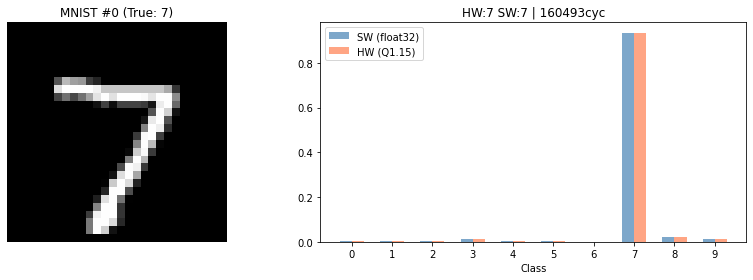

In [6]:
# =========================================================================
# Single Image Test
# =========================================================================
def load_custom_image(path):
    """Load a custom image file and preprocess for MNIST LeNet-5.
    - Convert to grayscale, resize to 28x28
    - Auto-invert if background is bright (MNIST = white digit on black bg)
    - Normalize to [0, 1] (same as transforms.ToTensor())
    """
    pil = Image.open(path).convert('L').resize((28, 28), Image.BILINEAR)
    arr = np.array(pil, dtype=np.float32) / 255.0
    # MNIST convention: white digit on black background
    # If mean > 0.5, the background is bright to invert
    if arr.mean() > 0.5:
        arr = 1.0 - arr
    return arr.reshape(28, 28, 1)  # (H, W, C=1)

def test_image(idx_or_path):
    """Test a single image on both SW and HW softmax.
    
    Args:
        idx_or_path: int  to MNIST test set index (0-9999)
                     str  to path to custom image (e.g. '../random2.jpg')
    """
    if isinstance(idx_or_path, str):
        # Custom image from file
        img = load_custom_image(idx_or_path)
        yt = -1  # Unknown ground truth
        label_str = f'Custom: {os.path.basename(idx_or_path)}'
    else:
        # MNIST test set
        img = test_data[idx_or_path]
        yt = int(test_label[idx_or_path])
        label_str = f'MNIST #{idx_or_path} (True: {yt})'

    with torch.no_grad():
        logits = model(torch.tensor(img.transpose(2,0,1)).unsqueeze(0)).numpy().flatten()
        psw = F.softmax(torch.tensor(logits), dim=0).numpy()
    phw, hp, info = runner.run(logits); sp = int(np.argmax(psw))

    match_str = ''
    if yt >= 0:
        match_str = ' | MATCH ✓' if hp == yt else ' | MISMATCH ✗'

    print(f"\n{'='*60}")
    print(f" {label_str}")
    print(f" SW prediction: {sp} | HW prediction: {hp}{match_str}")
    print(f"{'='*60}")
    print(f" Logits: [{np.min(logits):.4f}, {np.max(logits):.4f}]")
    print(f" MAE: {np.mean(np.abs(phw-psw)):.6f} | KL: {kl_div(psw,phw):.6f}")
    print(f" HW Sum: {np.sum(phw):.6f} | Valid: {info['valid']}")
    print(f" Total: {info['total']} cyc | P1: {info['p1']} | P2: {info['p2']}")
    print(f" Stall: {info['stall']} | Compute: {info['compute']}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img[:,:,0], cmap='gray'); axes[0].axis('off')
    axes[0].set_title(label_str)

    x = np.arange(10)
    axes[1].bar(x - 0.15, psw, 0.3, label='SW (float32)', alpha=0.7, color='steelblue')
    axes[1].bar(x + 0.15, phw, 0.3, label='HW (Q1.15)', alpha=0.7, color='coral')
    axes[1].set_xticks(x); axes[1].set_xlabel('Class')
    axes[1].legend()
    axes[1].set_title(f'HW:{hp} SW:{sp} | {info["total"]}cyc')
    plt.tight_layout(); plt.show()

# Test with MNIST dataset
test_image(0)


 Custom: random.jpg
 SW prediction: 5 | HW prediction: 5
 Logits: [-4.7351, 2.5636]
 MAE: 0.000071 | KL: 0.000062
 HW Sum: 0.999939 | Valid: True
 Total: 170730 cyc | P1: 90364 | P2: 80352
 Stall: 0 | Compute: 71


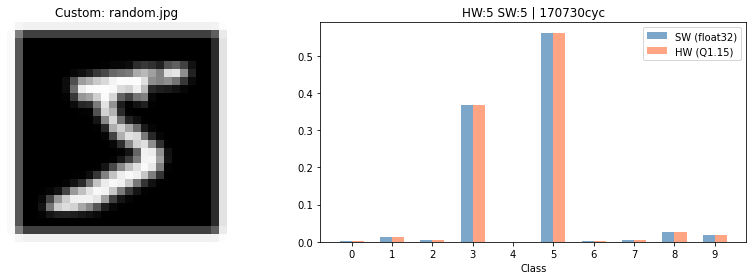

In [7]:
test_image("../random.jpg")


 Custom: random2.jpg
 SW prediction: 1 | HW prediction: 1
 Logits: [-1.6993, 1.2899]
 MAE: 0.000421 | KL: 0.004221
 HW Sum: 0.995789 | Valid: True
 Total: 170535 cyc | P1: 90077 | P2: 80444
 Stall: 0 | Compute: 71


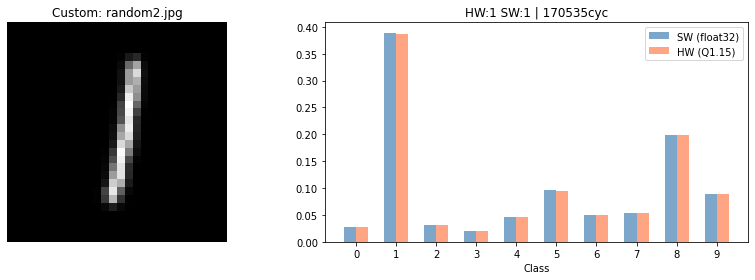

In [8]:
test_image("../random2.jpg")


 Custom: random3.jpg
 SW prediction: 3 | HW prediction: 3
 Logits: [-4.0097, 3.6788]
 MAE: 0.000009 | KL: -0.000030
 HW Sum: 1.000031 | Valid: True
 Total: 169613 cyc | P1: 89049 | P2: 80550
 Stall: 0 | Compute: 71


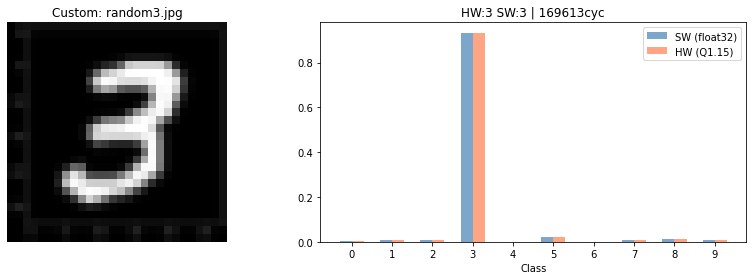

In [9]:
test_image("../random3.jpg")


 Custom: random4.jpg
 SW prediction: 9 | HW prediction: 9
 Logits: [-2.7114, 1.5534]
 MAE: 0.000323 | KL: 0.003241
 HW Sum: 0.996765 | Valid: True
 Total: 171528 cyc | P1: 91658 | P2: 79856
 Stall: 0 | Compute: 71


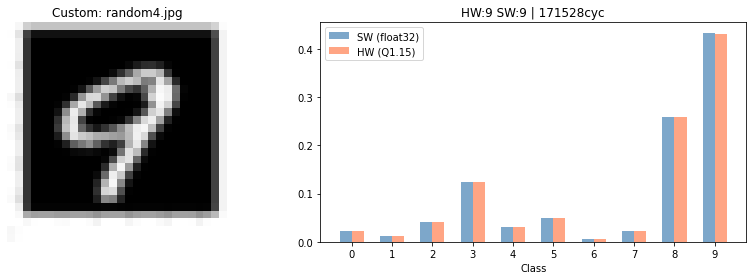

In [10]:
test_image("../random4.jpg")


 Custom: random5.png
 SW prediction: 0 | HW prediction: 0
 Logits: [-2.2488, 4.2723]
 MAE: 0.000012 | KL: 0.000000
 HW Sum: 1.000000 | Valid: True
 Total: 172357 cyc | P1: 91614 | P2: 80729
 Stall: 0 | Compute: 71


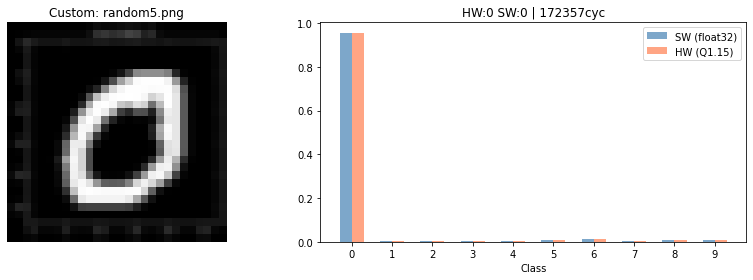

In [11]:
test_image("../random5.png")

In [12]:
# =========================================================================
# Cell 8: Cleanup
# =========================================================================
try: in_buf.freebuffer(); out_buf.freebuffer()
except: pass
print('Buffers freed. Done.')

Buffers freed. Done.
